# JaxFEM – Kragarm (Lineare Elastizität)

Kragarm: **L = 10 m**, Querschnitt **b = h = 0,5 m**, Einzellast **F = 10 kN** (vertikal nach unten, an der freien Seite).

Analytische Lösung (Euler-Bernoulli): $w_{max} = \frac{F L^3}{3 E I}$

In [7]:
import jax
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt

from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.generate_mesh import get_meshio_cell_type, Mesh, rectangle_mesh

print("JAX-Version:", jax.__version__)

JAX-Version: 0.6.2


## 1. Materialparameter & Schwache Form

Einheiten: **kN** und **m** → E in kN/m².

Stahl: E = 210 000 kN/m², ν = 0,3.  
Flächenlast rechte Kante: t = F / h = 10 kN / 0,5 m = 20 kN/m².

**Vorzeichenkonvention JaxFEM:**  gibt eine Traktionsgröße zurück, bei der ein positiver y-Wert eine Kraft nach **unten** bewirkt (Kraft = −surface_map in die Systemmatrix).

In [13]:
# Geometrie [m]
Lx = 10.0   # Länge
Ly = 1    # Höhe des Querschnitts

# Materialparameter  (Einheiten: kN, m)
E  = 210_000.0  # kN/m²  (Stahl)
nu = 0.3
mu     = E / (2.0 * (1.0 + nu))
lmbda  = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))

# Flächenlast an der rechten Kante [kN/m²]
# Konvention JaxFEM: surface_map gibt "Traction" zurück, positives t_y = Kraft nach UNTEN
F_total = 10.0          # kN
t_y     = F_total / Ly  # kN/m²  (positiv = nach unten in JaxFEM)


class LinearElasticity2D(Problem):
    def get_tensor_map(self):
        def stress(u_grad):
            epsilon = 0.5 * (u_grad + u_grad.T)
            sigma = lmbda * np.trace(epsilon) * np.eye(self.dim) + 2.0 * mu * epsilon
            return sigma
        return stress

    def get_surface_maps(self):
        # positives t_y → Kraft in -y-Richtung (nach unten)
        def surface_map(u, x):
            return np.array([0.0, t_y])
        return [surface_map]

## 2. Netz erzeugen

2-D Scheibe mit QUAD4-Elementen: 40 Elemente in x-Richtung, 4 in y-Richtung.

In [14]:
ele_type  = "QUAD4"
cell_type = get_meshio_cell_type(ele_type)

meshio_mesh = rectangle_mesh(Nx=40, Ny=4, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
print("Knoten:", len(meshio_mesh.points), "  Elemente:", len(meshio_mesh.cells_dict[cell_type]))

Knoten: 205   Elemente: 160


## 3. Randbedingungen

- **Dirichlet** (Einspannung): linke Seite → u_x = u_y = 0
- **Neumann** (Kraft): rechte Seite → Flächenlast t_y nach unten

In [15]:
def left(point):
    return np.isclose(point[0], 0.0, atol=1e-5)

def right(point):
    return np.isclose(point[0], Lx, atol=1e-5)

def zero(point):
    return 0.0

# Beide Verschiebungskomponenten an der linken Seite fixieren
dirichlet_bc_info = [[left, left], [0, 1], [zero, zero]]

# Neumann-Rand (rechte Seite)
location_fns = [right]

## 4. Lösen

Der JAX-eigene CG-Solver ist bei Biegeproblemen schlecht konditioniert.  
Wir verwenden daher den direkten **umfpack**-Löser von scipy.

In [16]:
problem = LinearElasticity2D(
    mesh=mesh,
    vec=2,
    dim=2,
    ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)
sol = solver(problem, solver_options={"umfpack_solver": {}})
print("Lösung berechnet. Shape:", sol[0].shape)

[04-19 17:26:53][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-19 17:26:53][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[04-19 17:26:53][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[04-19 17:26:53][DEBUG] jax_fem: Done pre-computations, took 0.007934808731079102 [s]
[04-19 17:26:53][INFO] jax_fem: Solving a problem with 160 cells, 205x2 = 410 dofs.
[04-19 17:26:53][INFO] jax_fem: Element type is QUAD4, using 4 quad points per element.
[04-19 17:26:53][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-19 17:26:53][DEBUG] jax_fem: Start timing
[04-19 17:26:53][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-19 17:26:53][DEBUG] jax_fem: Function split_and_compute_cell took 0.0322 seconds
[04-19 17:26:53][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-19 17:26:53][DEBUG] jax_fem: Before, l_2 res = 4.6770717334674305, relative l_2 r

Lösung berechnet. Shape: (205, 2)


## 5. Ergebnis & Vergleich mit analytischer Lösung

FEM  w_max = -167.77 mm
Ana. w_max = -190.48 mm  (Euler-Bernoulli)
Abweichung: 11.9 %


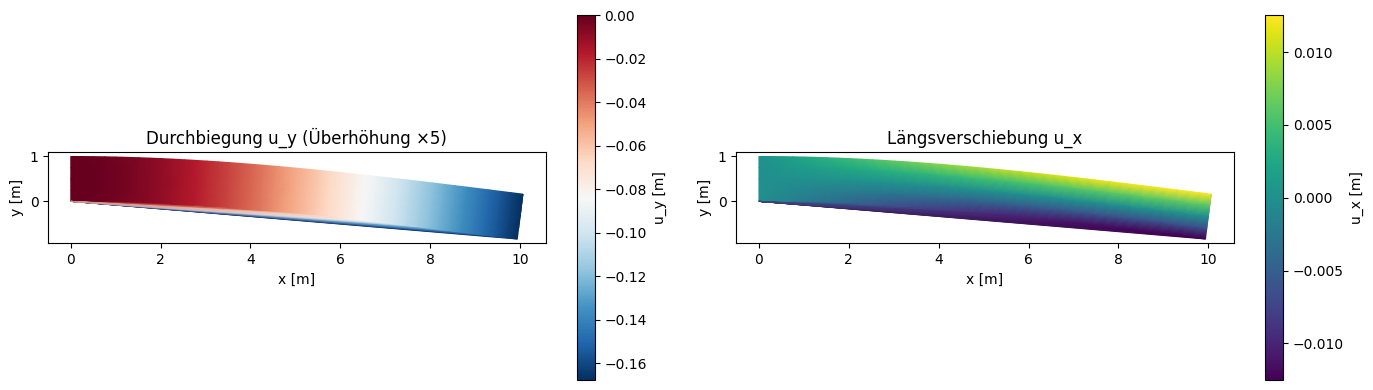

In [17]:
points = meshio_mesh.points
ux = sol[0][:, 0]
uy = sol[0][:, 1]

# Maximale Durchbiegung (FEM)
w_fem = float(np.min(uy))

# Analytische Lösung (Euler-Bernoulli, 2-D: I = b*h³/12 mit b=1 m Tiefe)
I = 1.0 * Ly**3 / 12.0
w_ana = -F_total * Lx**3 / (3.0 * E * I)
print(f"FEM  w_max = {w_fem*1000:.2f} mm")
print(f"Ana. w_max = {w_ana*1000:.2f} mm  (Euler-Bernoulli)")
print(f"Abweichung: {abs(w_fem - w_ana) / abs(w_ana) * 100:.1f} %")

# Visualisierung (verformte Geometrie, überhöht)
scale = 5.0
x_def = points[:, 0] + scale * onp.array(ux)
y_def = points[:, 1] + scale * onp.array(uy)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sc0 = axes[0].tripcolor(x_def, y_def, onp.array(uy), shading="gouraud", cmap="RdBu_r")
plt.colorbar(sc0, ax=axes[0], label="u_y [m]")
axes[0].set_title(f"Durchbiegung u_y (Überhöhung ×{scale:.0f})")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].set_aspect("equal")

sc1 = axes[1].tripcolor(x_def, y_def, onp.array(ux), shading="gouraud", cmap="viridis")
plt.colorbar(sc1, ax=axes[1], label="u_x [m]")
axes[1].set_title("Längsverschiebung u_x")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()